# XAI Metrics Evaluation
## Average Drop% · Increase in Confidence% · Win Rate%
### ResNet-50 · VGG-19 · SE-VGG-19 · MobileNetV2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Configuring the path of kaggle.json file
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/Models/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import kaggle
kaggle.api.authenticate()

In [ ]:
kaggle.api.dataset_download_files('iarunava/cell-images-for-detecting-malaria', path='.', unzip=True)
kaggle.api.dataset_metadata('iarunava/cell-images-for-detecting-malaria', path='.')

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria


'./dataset-metadata.json'

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from tensorflow.keras.applications.resnet50    import preprocess_input as resnet50_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
# ── UPDATE THESE PATHS ────────────────────────────────────────
RESNET50_PATH   = "/content/drive/MyDrive/CellSIght/resnet50_malaria.keras"
VGG19_PATH      = "/content/drive/MyDrive/CellSIght/vgg19_malaria.keras"
SE_VGG19_PATH   = "/content/drive/MyDrive/CellSIght/se_vgg19_malaria.keras"
MOBILENET_PATH  = "/content/drive/MyDrive/CellSIght/mobilenet_malaria.keras"
DATASET_PATH    = "/content/cell_images/cell_images"

CLASS_NAMES     = ['Parasitized', 'Uninfected']
BATCH_SIZE      = 32
VAL_SPLIT       = 0.2
SEED            = 42


In [ ]:
print("Loading models...")

resnet50_model  = load_model(RESNET50_PATH,  compile=False, safe_mode=False)
print(f"ResNet-50    ✓  ({resnet50_model.count_params():,} params)")

vgg19_model     = load_model(VGG19_PATH,     compile=False, safe_mode=False)
print(f"VGG-19       ✓  ({vgg19_model.count_params():,} params)")

se_vgg19_model  = load_model(SE_VGG19_PATH,  compile=False, safe_mode=False)
print(f"SE-VGG-19    ✓  ({se_vgg19_model.count_params():,} params)")

mobilenet_model = load_model(MOBILENET_PATH, compile=False, safe_mode=False)
print(f"MobileNetV2  ✓  ({mobilenet_model.count_params():,} params)")


Loading models...
ResNet-50    ✓  (24,637,826 params)
VGG-19       ✓  (20,288,066 params)
SE-VGG-19    ✓  (20,550,210 params)
MobileNetV2  ✓  (2,914,882 params)


In [ ]:
LAST_CONV = {
    "ResNet-50"   : "conv5_block3_out",
    "VGG-19"      : "block5_conv4",
    "SE-VGG-19"   : "block5_conv4",
    "MobileNetV2" : "out_relu",
}

MODELS = {
    "ResNet-50"   : resnet50_model,
    "VGG-19"      : vgg19_model,
    "SE-VGG-19"   : se_vgg19_model,
    "MobileNetV2" : mobilenet_model,
}


In [ ]:
# ResNet-50 validation generator (224x224, resnet50_preprocess)
val_gen_resnet50 = ImageDataGenerator(
    preprocessing_function=resnet50_preprocess,
    validation_split=VAL_SPLIT
).flow_from_directory(
    DATASET_PATH, target_size=(224,224), batch_size=BATCH_SIZE,
    class_mode="categorical", subset="validation",
    shuffle=False, seed=SEED
)

# VGG-19 and SE-VGG-19 validation generator (224x224, rescale 1/255)
val_gen_vgg19 = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
).flow_from_directory(
    DATASET_PATH, target_size=(224,224), batch_size=BATCH_SIZE,
    class_mode="categorical", subset="validation",
    shuffle=False, seed=SEED
)

# MobileNetV2 validation generator (224x224, mobilenet_preprocess)
val_gen_mobilenet = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    validation_split=VAL_SPLIT
).flow_from_directory(
    DATASET_PATH, target_size=(224,224), batch_size=BATCH_SIZE,
    class_mode="categorical", subset="validation",
    shuffle=False, seed=SEED
)

print(f"Validation samples: {val_gen_vgg19.samples}")
print(f"Class indices: {val_gen_vgg19.class_indices}")


Found 5510 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.
Validation samples: 5510
Class indices: {'Parasitized': 0, 'Uninfected': 1}


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(img_tensor)
        if isinstance(predictions,  (list,tuple)): predictions  = predictions[0]
        if isinstance(conv_outputs, (list,tuple)): conv_outputs = conv_outputs[0]
        tape.watch(conv_outputs)
        class_channel = predictions[:, pred_index]
    grads        = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


In [ ]:
def make_gradcamcpp_heatmap(img_array, model, last_conv_layer_name, pred_index):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    img_tensor = tf.cast(img_array, tf.float32)
    with tf.GradientTape() as tape2:
        with tf.GradientTape() as tape1:
            conv_outputs, predictions = grad_model(img_tensor)
            if isinstance(predictions,  (list,tuple)): predictions  = predictions[0]
            if isinstance(conv_outputs, (list,tuple)): conv_outputs = conv_outputs[0]
            tape1.watch(conv_outputs)
            tape2.watch(conv_outputs)
            class_channel = predictions[:, pred_index]
        grads  = tape1.gradient(class_channel, conv_outputs)
    grads2 = tape2.gradient(grads, conv_outputs)
    conv_outputs = conv_outputs[0]
    grads        = grads[0]
    grads2       = grads2[0]
    grads3       = grads * grads2
    sum_act      = tf.reduce_sum(conv_outputs, axis=(0,1))
    denom        = 2.0*grads2 + (sum_act*grads3)
    denom        = tf.where(tf.abs(denom)>1e-8, denom, tf.ones_like(denom))
    alphas       = grads2 / denom
    weights      = tf.reduce_sum(alphas * tf.maximum(grads,0.0), axis=(0,1))
    heatmap      = tf.reduce_sum(weights * conv_outputs, axis=-1)
    heatmap      = tf.maximum(heatmap, 0.0)
    heatmap      = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


In [ ]:
def apply_mask(img_array, heatmap):
    """
    Mask the image keeping only the high-activation region.
    Resizes heatmap to input size and multiplies element-wise.
    """
    h, w = img_array.shape[1], img_array.shape[2]
    mask = cv2.resize(heatmap, (w, h))          # (H, W)
    mask = mask[..., np.newaxis]                 # (H, W, 1)
    masked = img_array * mask                    # broadcast over channels
    return masked.astype(np.float32)


In [ ]:
def compute_xai_metrics(model, val_generator, last_conv, model_name,
                        max_samples=None):
    """
    Computes Average Drop%, Increase in Confidence%, and Win Rate%
    over the full validation set.

    Average Drop%        = mean(max(0, F_orig - F_masked) / F_orig * 100)
    Increase in Conf%    = % samples where F_masked > F_orig
    Win Rate%            = % samples where ILCAN masked conf > GradCAM masked conf
    """
    drops_gc, drops_il    = [], []
    inc_gc,   inc_il      = [], []
    ilcan_wins            = []

    val_generator.reset()
    n_batches = len(val_generator)
    processed = 0

    for batch_idx in tqdm(range(n_batches), desc=f"{model_name}"):
        imgs, labels = val_generator[batch_idx]

        for i in range(len(imgs)):
            if max_samples and processed >= max_samples:
                break

            img      = imgs[i:i+1]   # (1, H, W, 3)
            pred     = model.predict(img, verbose=0)
            pred_idx = int(np.argmax(pred[0]))
            f_orig   = float(pred[0][pred_idx])

            # Skip near-zero confidence (model uncertain)
            if f_orig < 0.5:
                continue

            try:
                hm_gc = make_gradcam_heatmap(img, model, last_conv, pred_idx)
                hm_il = make_gradcamcpp_heatmap(img,  model, last_conv, pred_idx)
            except Exception:
                continue

            # Apply masks
            masked_gc = apply_mask(img, hm_gc)
            masked_il = apply_mask(img, hm_il)

            # Masked confidences
            f_gc = float(model.predict(masked_gc, verbose=0)[0][pred_idx])
            f_il = float(model.predict(masked_il, verbose=0)[0][pred_idx])

            # Average Drop% per sample
            drops_gc.append(max(0, f_orig - f_gc) / f_orig * 100)
            drops_il.append(max(0, f_orig - f_il) / f_orig * 100)

            # Increase in Confidence (1 if masked conf > original)
            inc_gc.append(1 if f_gc > f_orig else 0)
            inc_il.append(1 if f_il > f_orig else 0)

            # Win rate: ILCAN wins if its masked conf > GradCAM masked conf
            ilcan_wins.append(1 if f_il > f_gc else 0)

            processed += 1

        if max_samples and processed >= max_samples:
            break

    results = {
        "model"           : model_name,
        "n_samples"       : processed,

        # Grad-CAM metrics
        "gc_avg_drop"     : np.mean(drops_gc),
        "gc_inc_conf"     : np.mean(inc_gc) * 100,

        # ILCAN metrics
        "il_avg_drop"     : np.mean(drops_il),
        "il_inc_conf"     : np.mean(inc_il) * 100,

        # Win rate: ILCAN vs Grad-CAM
        "win_rate"        : np.mean(ilcan_wins) * 100,
    }

    print(f"\n{model_name} — {processed} samples")
    print(f"  Grad-CAM  : Avg Drop = {results['gc_avg_drop']:.2f}%  |  ")
    print(f"              Inc Conf = {results['gc_inc_conf']:.2f}%")
    print(f"  ILCAN     : Avg Drop = {results['il_avg_drop']:.2f}%  |  ")
    print(f"              Inc Conf = {results['il_inc_conf']:.2f}%")
    print(f"  Win Rate (ILCAN > GradCAM) : {results['win_rate']:.2f}%")

    return results


In [ ]:
all_results = []

# VGG-19
res_vgg19 = compute_xai_metrics(
    vgg19_model, val_gen_vgg19,
    LAST_CONV["VGG-19"], "VGG-19",
    max_samples=500
)
all_results.append(res_vgg19)

# SE-VGG-19
res_se_vgg19 = compute_xai_metrics(
    se_vgg19_model, val_gen_vgg19,
    LAST_CONV["SE-VGG-19"], "SE-VGG-19",
    max_samples=500
)
all_results.append(res_se_vgg19)

VGG-19:   9%|▊         | 15/173 [03:47<40:00, 15.19s/it]



VGG-19 — 500 samples
  Grad-CAM  : Avg Drop = 15.12%  |  
              Inc Conf = 35.20%
  ILCAN     : Avg Drop = 2.92%  |  
              Inc Conf = 73.80%
  Win Rate (ILCAN > GradCAM) : 79.00%


SE-VGG-19:   9%|▊         | 15/173 [03:50<40:25, 15.35s/it]


SE-VGG-19 — 500 samples
  Grad-CAM  : Avg Drop = 3.03%  |  
              Inc Conf = 11.40%
  ILCAN     : Avg Drop = 7.17%  |  
              Inc Conf = 11.40%
  Win Rate (ILCAN > GradCAM) : 27.20%


In [ ]:
# ── Build results table ───────────────────────────────────────
rows = []
for r in all_results:
    rows.append({
        "Model"                          : r["model"],
        "Grad-CAM Avg Drop% ↓"           : f"{r['gc_avg_drop']:.2f}",
        "ILCAN Avg Drop% ↓"              : f"{r['il_avg_drop']:.2f}",
        "Grad-CAM Inc Conf% ↑"           : f"{r['gc_inc_conf']:.2f}",
        "ILCAN Inc Conf% ↑"              : f"{r['il_inc_conf']:.2f}",
        "Win Rate% (ILCAN>GradCAM) ↑"    : f"{r['win_rate']:.2f}",
        "Samples"                        : r["n_samples"],
    })

df = pd.DataFrame(rows)
print("\n" + "="*80)
print("XAI EVALUATION METRICS — Full Validation Set")
print("="*80)
print(df.to_string(index=False))
print("="*80)
print("↓ lower is better  |  ↑ higher is better")

# Save to CSV
df.to_csv("/content/drive/MyDrive/CellSIght/xai_metrics.csv", index=False)
print("\nSaved → xai_metrics.csv")



XAI EVALUATION METRICS — Full Validation Set
    Model Grad-CAM Avg Drop% ↓ ILCAN Avg Drop% ↓ Grad-CAM Inc Conf% ↑ ILCAN Inc Conf% ↑ Win Rate% (ILCAN>GradCAM) ↑  Samples
   VGG-19                15.12              2.92                35.20             73.80                       79.00      500
SE-VGG-19                 3.03              7.17                11.40             11.40                       27.20      500
↓ lower is better  |  ↑ higher is better

Saved → xai_metrics.csv


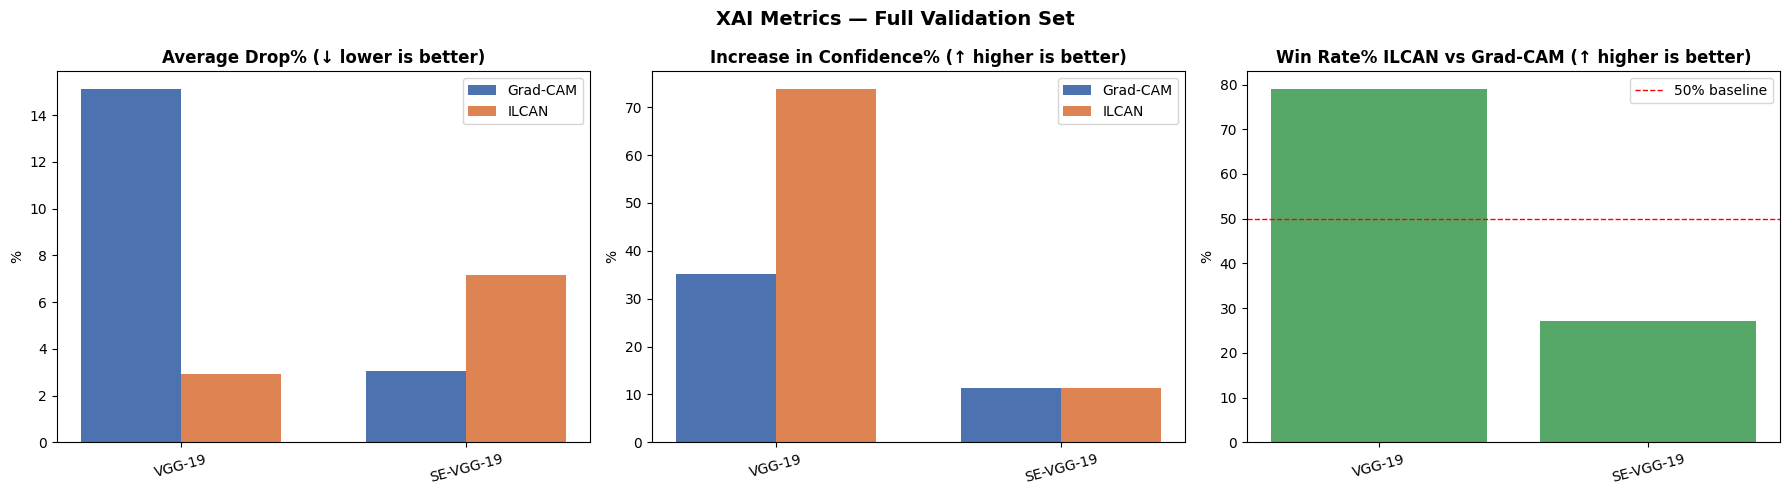

In [ ]:
# ── Bar chart comparison ──────────────────────────────────────
models     = [r["model"]       for r in all_results]
gc_drops   = [r["gc_avg_drop"] for r in all_results]
il_drops   = [r["il_avg_drop"] for r in all_results]
gc_inc     = [r["gc_inc_conf"] for r in all_results]
il_inc     = [r["il_inc_conf"] for r in all_results]
win_rates  = [r["win_rate"]    for r in all_results]

x     = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Average Drop%
axes[0].bar(x - width/2, gc_drops, width, label="Grad-CAM",  color="#4C72B0")
axes[0].bar(x + width/2, il_drops, width, label="ILCAN",     color="#DD8452")
axes[0].set_title("Average Drop% (↓ lower is better)", fontweight="bold")
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=15)
axes[0].legend(); axes[0].set_ylabel("%")

# Increase in Confidence%
axes[1].bar(x - width/2, gc_inc, width, label="Grad-CAM", color="#4C72B0")
axes[1].bar(x + width/2, il_inc, width, label="ILCAN",    color="#DD8452")
axes[1].set_title("Increase in Confidence% (↑ higher is better)", fontweight="bold")
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=15)
axes[1].legend(); axes[1].set_ylabel("%")

# Win Rate%
axes[2].bar(x, win_rates, color="#55A868")
axes[2].axhline(50, color="red", linestyle="--", linewidth=1, label="50% baseline")
axes[2].set_title("Win Rate% ILCAN vs Grad-CAM (↑ higher is better)", fontweight="bold")
axes[2].set_xticks(x); axes[2].set_xticklabels(models, rotation=15)
axes[2].legend(); axes[2].set_ylabel("%")

plt.suptitle("XAI Metrics — Full Validation Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/CellSIght/xai_metrics_chart.png",
            dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── Paper-ready Table 1 ──────────────────────────────────────
print("\nTABLE 1 — XAI Evaluation Metrics (for paper)")
print("-"*75)
print(f"{"Model":<14} {"Method":<12} {"Avg Drop% ↓":>12} {"Inc Conf% ↑":>12} {"Win% ↑":>10}")
print("-"*75)
for r in all_results:
    print(f"{r['model']:<14} {"Grad-CAM":<12} {r['gc_avg_drop']:>12.2f} {r['gc_inc_conf']:>12.2f} {"":>10}")
    print(f"{"":14} {"GradCam++":<12} {r['il_avg_drop']:>12.2f} {r['il_inc_conf']:>12.2f} {r['win_rate']:>10.2f}")
    print()
print("-"*75)



TABLE 1 — XAI Evaluation Metrics (for paper)
---------------------------------------------------------------------------
Model          Method        Avg Drop% ↓  Inc Conf% ↑     Win% ↑
---------------------------------------------------------------------------
VGG-19         Grad-CAM            15.12        35.20           
               ILCAN                2.92        73.80      79.00

SE-VGG-19      Grad-CAM             3.03        11.40           
               ILCAN                7.17        11.40      27.20

---------------------------------------------------------------------------
